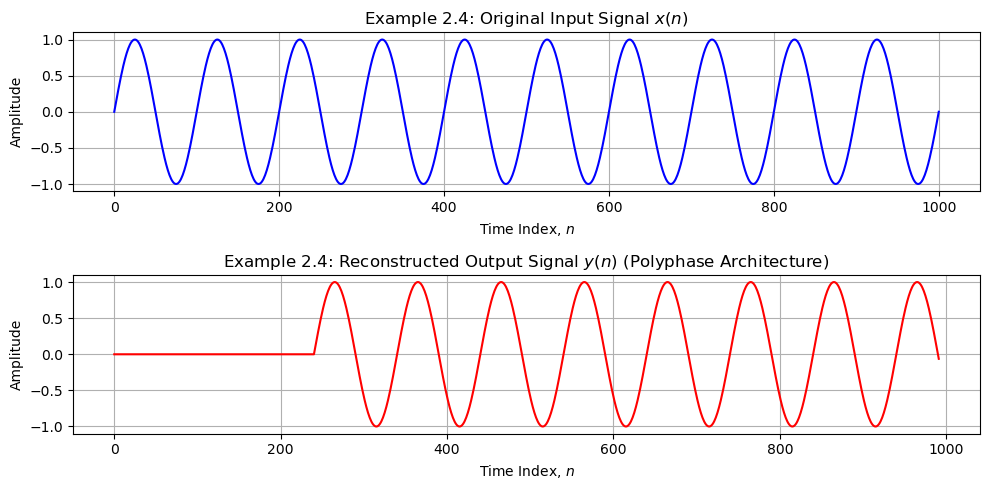

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import remez


def opt_filter(filtorder: int, N: int):
    """
    Python translation of opt_filter.m
    Designs the optimal lowpass prototype filter for Pseudo-QMF banks
    using the Parks-McClellan (remez) algorithm.
    """
    stopedge = 1.0 / N       # Stopband edge fixed at (1/N)*pi
    passedge = 1.0 / (4 * N) # Initial passband edge
    tol = 1e-6
    step = 0.1 * passedge
    way = -1
    pcost = 10.0
    flag = False

    while not flag:
        p = remez(filtorder + 1, [0, passedge, stopedge, 1.0], [1, 0], weight=[5, 1], fs=2.0)
        
        P = np.fft.fft(p, 4096)
        OptRange = int(np.floor(2048 / N))
        phi = np.zeros(OptRange)
        
        for k in range(1, OptRange + 1):
            phi[k-1] = np.abs(P[OptRange - k + 1])**2 + np.abs(P[k - 1])**2
            
        tcost = np.max(np.abs(phi - 1.0))
        
        if tcost > pcost:
            step /= 2.0
            way = -way
            
        if np.abs(pcost - tcost) < tol:
            flag = True
            
        pcost = tcost
        passedge += way * step
        
    return p, passedge


def make_bank(p: np.ndarray, N: int):
    """
    Python translation of make_bank.m (Cosine Modulation, Eq 2.35)
    """
    L = len(p)
    H = np.zeros((N, L))
    n = np.arange(L)
    
    for i in range(N):
        H[i, :] = 2 * p * np.cos((np.pi / N) * (i + 0.5) * (n - (L - 1) / 2.0) + ((-1)**i) * (np.pi / 4.0))
        
    F = np.fliplr(H)
    return H, F



# 2. Example 2.4 Execution

N = 16                                
K = 8                                 
L = 2 * K * N                         # Filter length L = 256

# Now opt_filter and make_bank exist in memory!
hopt, passedge = opt_filter(L - 1, N)
H, F = make_bank(hopt, N)

H_scaled = np.sqrt(N) * H.T           
F_scaled = np.sqrt(N) * F.T          

xn = np.sin(2 * np.pi * 0.01 * np.arange(1001))
ITER = len(xn)

x = np.zeros(N)
num_poly = L // N
X = np.zeros((N, num_poly))
Y = np.zeros((num_poly, N))
yn = np.zeros(int(np.floor(ITER / N) * N))


E = np.zeros((N, num_poly, N))
R = np.zeros((N, num_poly, N))

for i in range(N):
    E[:, :, i] = H_scaled[:, i].reshape((N, num_poly), order='F')
    R[:, :, i] = np.flipud(F_scaled[:, i].reshape((N, num_poly), order='F'))


for n in range(1, ITER + 1):
    x = np.concatenate(([xn[n - 1]], x[:-1]))
    if n % N == 0:
        X = np.column_stack((x, X[:, :-1]))
        xD = np.zeros(N)
        for i in range(N):
            xD[i] = np.sum(E[:, :, i] * X)
            
        Y = np.vstack((xD, Y[:-1, :]))
        y = np.zeros(N)
        for i in range(N):
            y += R[:, :, i] @ Y[:, i]
            
        yn[n - N : n] = y[::-1]

# Plot Results
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(xn, 'b')
plt.title('Example 2.4: Original Input Signal $x(n)$')
plt.xlabel('Time Index, $n$')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(yn, 'r')
plt.title('Example 2.4: Reconstructed Output Signal $y(n)$ (Polyphase Architecture)')
plt.xlabel('Time Index, $n$')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()